# Factor Backtest

Walk-forward, out-of-sample evaluation of the microstructure factors against
the next-`horizon`-tick bid/ask return.

In [14]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from utils import load_book
from factors import compute_factors
from data_splits import holdout_split, rolling_windows
from factor_backtest import walk_forward_ic, summarize_ic
from main import data_prep

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load data and build walk-forward windows

Reserve the final hour as a hold-out (untouched), then tile rolling 60-min
windows (50 train / 10 val) over the remaining session.

In [15]:
trainable, windows = data_prep()
print(f"walk-forward windows: {len(windows)}")

trainable: 2,935,275 rows | holdout: 400,787 rows

walk-forward windows: 28


## 2. Walk-forward IC and summary

`walk_forward_ic` computes, per window's validation slice, the Spearman IC of
each factor vs each forward target. `summarize_ic` aggregates across windows.

> Reminder: IR magnitudes here are inflated by overlapping labels
> ($n_\text{eff} \approx n/\text{horizon}$) — read `mean_ic` as the edge, not IR.

In [16]:
ic_df = walk_forward_ic(windows, method="spearman")
# ic_df = walk_forward_ic(windows, method="pearson")
summary = summarize_ic(ic_df)
summary

,factor,target,n_windows,mean_ic,ic_std
0,change_in_spread,ask_px_00_ret,28.0000,-0.1227,0.0151
1,change_in_spread,bid_px_00_ret,28.0000,0.1302,0.0178
2,change_in_spread,mid_px_00_ret,28.0000,0.0037,0.0158
3,net_liquidity_flow,ask_px_00_ret,28.0000,0.0029,0.0342
4,net_liquidity_flow,bid_px_00_ret,28.0000,-0.0155,0.0325
5,net_liquidity_flow,mid_px_00_ret,28.0000,-0.0072,0.0341
6,obi_ratio,ask_px_00_ret,28.0000,0.0629,0.0215
7,obi_ratio,bid_px_00_ret,28.0000,0.0633,0.0224
8,obi_ratio,mid_px_00_ret,28.0000,0.0647,0.0224
9,trend_ratio,ask_px_00_ret,28.0000,0.0314,0.0341


## 3. IC distribution by factor and target

Box plot of the actual per-window IC values (not a symmetric ±std). Box spans
Q1–median–Q3; whiskers mark the 5th–95th percentiles across the 28 windows.

Same-sign boxes across bid/ask = directional signal; opposite-sign = spread
signal. A box clearly off zero = consistent edge.

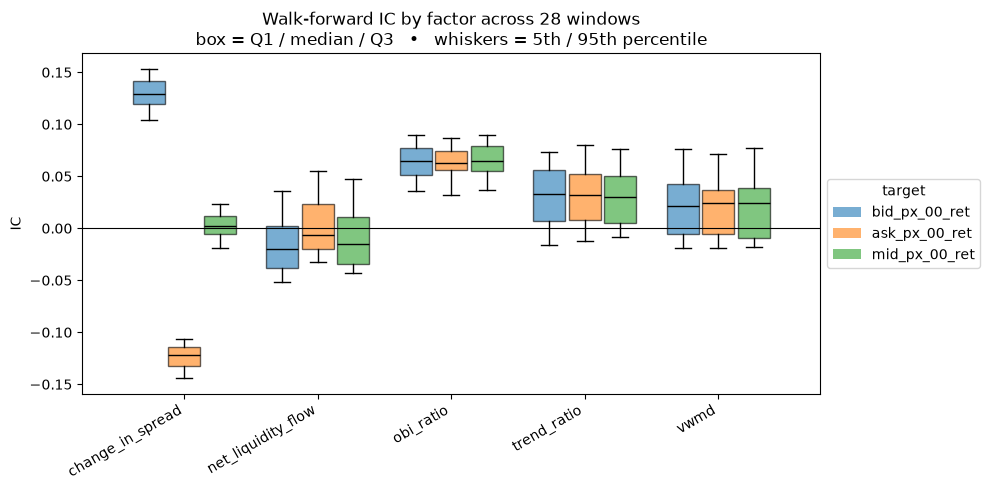

In [25]:
factors = sorted(ic_df["factor"].unique())
targets = list(ic_df["target"].unique())
width = 0.8 / len(targets)
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 5))
for j, t in enumerate(targets):
    data = [
        ic_df[(ic_df["factor"] == f) & (ic_df["target"] == t)]["ic"].dropna().values
        for f in factors
    ]
    positions = [i + (j - (len(targets) - 1) / 2) * width for i in range(len(factors))]
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width * 0.9,
        whis=(5, 95),  # whiskers at 5th / 95th percentile of the actual ICs
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
    )
    for box in bp["boxes"]:
        box.set(facecolor=colors[j], alpha=0.6)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(factors)))
ax.set_xticklabels(factors, rotation=30, ha="right")
ax.set_ylabel("IC")
ax.set_title(
    "Walk-forward IC by factor across 28 windows\n"
    "box = Q1 / median / Q3   •   whiskers = 5th / 95th percentile"
)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[j], alpha=0.6)
    for j in range(len(targets))
]
ax.legend(handles, targets, title="target", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

## 4. Per-window IC over time

Stability across the session: a real edge holds its sign window to window.

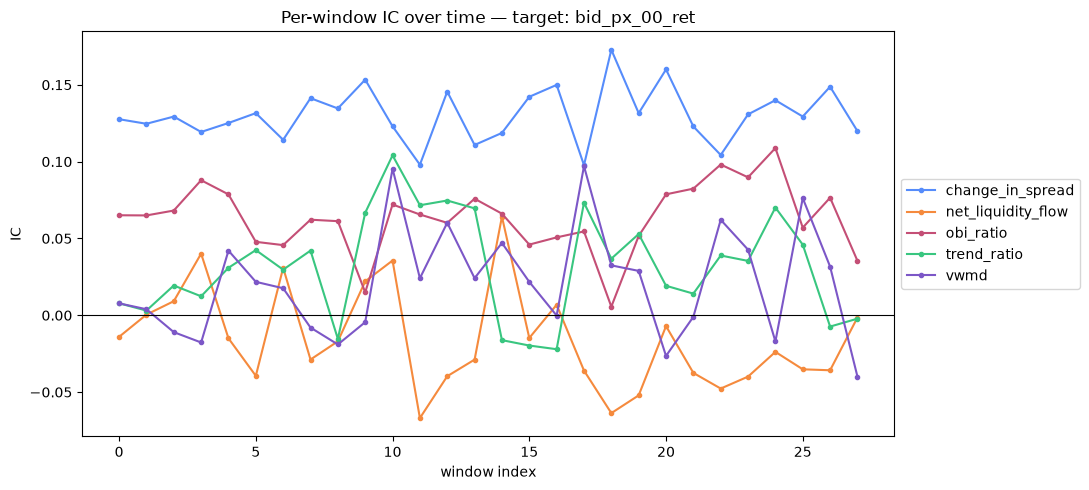

In [18]:
target = "bid_px_00_ret"
series = ic_df[ic_df["target"] == target].pivot(
    index="window", columns="factor", values="ic"
)

ax = series.plot(figsize=(11, 5), marker=".")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("window index")
ax.set_ylabel("IC")
ax.set_title(f"Per-window IC over time — target: {target}")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

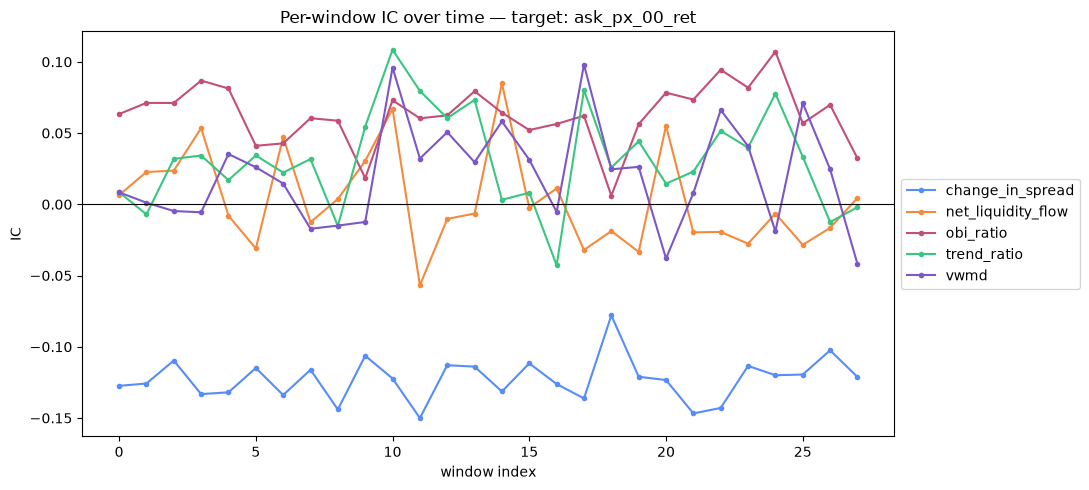

In [19]:
target = "ask_px_00_ret"
series = ic_df[ic_df["target"] == target].pivot(
    index="window", columns="factor", values="ic"
)

ax = series.plot(figsize=(11, 5), marker=".")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("window index")
ax.set_ylabel("IC")
ax.set_title(f"Per-window IC over time — target: {target}")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

## 5. Factor correlation heatmap

Highly correlated factors carry redundant information — useful to know before
feeding them to Lasso. Computed on the trainable set (hold-out excluded).

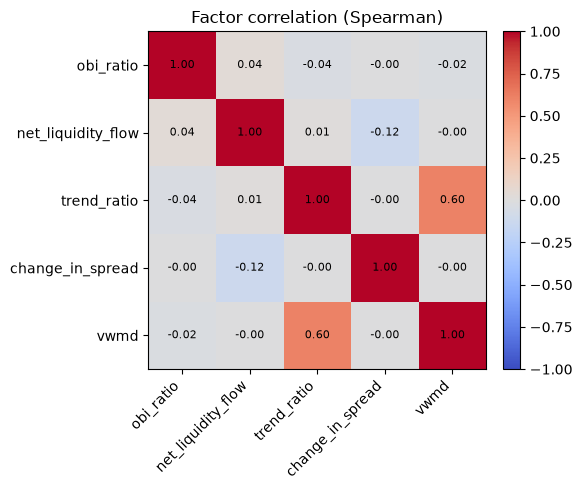

In [20]:
factor_corr = compute_factors(trainable).corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(factor_corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(factor_corr)))
ax.set_yticks(range(len(factor_corr)))
ax.set_xticklabels(factor_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(factor_corr.index)
for i in range(len(factor_corr)):
    for j in range(len(factor_corr)):
        ax.text(j, i, f"{factor_corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Factor correlation (Spearman)")
plt.tight_layout()
plt.show()